In [1]:
!pip install torch transformers pandas

In [2]:
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback, RobertaModel, RobertaTokenizer
from torch.utils.data import DataLoader, Dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.cluster import DBSCAN
from sklearn.utils.class_weight import compute_class_weight

In [3]:
from google.colab import drive
drive.mount('/content/drive/',force_remount=False)

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [4]:
leetcode_questions_df = pd.read_csv('/content/drive/MyDrive/thesis/leetcode/part4 feature-engineering/leetcode_questions_df.csv')

leetcode_questions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61834 entries, 0 to 61833
Data columns (total 31 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   username                            61834 non-null  object 
 1   country                             61834 non-null  object 
 2   contest_url                         61834 non-null  object 
 3   num_of_contest                      61834 non-null  int64  
 4   is_weekly                           61834 non-null  bool   
 5   rank                                61834 non-null  int64  
 6   score                               61834 non-null  int64  
 7   question_number                     61834 non-null  int64  
 8   question_language                   61834 non-null  object 
 9   question_code                       61834 non-null  object 
 10  number_of_lines                     61834 non-null  int64  
 11  names_set                           61834

In [5]:
leetcode_questions_df = leetcode_questions_df[leetcode_questions_df['question_language'] == 'java']
leetcode_questions_df = leetcode_questions_df[leetcode_questions_df['question_number'] > 1]
leetcode_questions_df = leetcode_questions_df.drop_duplicates(subset=['question_code'])

leetcode_questions_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4945 entries, 18 to 61822
Data columns (total 31 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   username                            4945 non-null   object 
 1   country                             4945 non-null   object 
 2   contest_url                         4945 non-null   object 
 3   num_of_contest                      4945 non-null   int64  
 4   is_weekly                           4945 non-null   bool   
 5   rank                                4945 non-null   int64  
 6   score                               4945 non-null   int64  
 7   question_number                     4945 non-null   int64  
 8   question_language                   4945 non-null   object 
 9   question_code                       4945 non-null   object 
 10  number_of_lines                     4945 non-null   int64  
 11  names_set                           4945 non-n

In [6]:
# Define rank thresholds
high_rank_threshold = 0.01
low_rank_threshold = 0.05


leetcode_questions_df["experienced_programmer"] = leetcode_questions_df["global_rank_percentile"] <= low_rank_threshold


high_rank_df = leetcode_questions_df[leetcode_questions_df["global_rank_percentile"] < high_rank_threshold]
low_rank_df = leetcode_questions_df[leetcode_questions_df["global_rank_percentile"] > low_rank_threshold]


filtered_df = pd.concat([high_rank_df, low_rank_df])

filtered_df.reset_index(drop=True, inplace=True)

leetcode_questions_df = filtered_df

In [7]:
leetcode_questions_df["experienced_programmer"].value_counts()

,count
experienced_programmer,
True,3796
False,474


In [8]:
leetcode_questions_df.describe()

,num_of_contest,rank,score,question_number,number_of_lines,token_count,variables_count,function_count,loop_count,condition_count,...,function_density,loop_density,condition_density,comment_tokens_density,contest_finish_time_total_seconds,question_finish_time_total_seconds,time_spent_per_question,global_rank_percentile,question_code_length,num_contests_participated
count,4270.000000,4270.000000,4270.000000,4270.000000,4270.000000,4270.000000,4270.000000,4270.000000,4270.000000,4270.000000,...,4270.000000,4270.000000,4270.000000,4270.000000,4270.000000,4270.000000,4270.000000,4270.000000,4270.000000,4270.000000
mean,300.783841,602.298829,15.644731,2.832319,57.470492,39.755504,21.531382,2.950117,3.648009,5.087588,...,0.050368,0.080418,0.107492,0.079717,3401.191335,1984.909133,971.817330,0.017801,1632.925293,10.774005
std,118.857426,350.036146,3.016394,0.778298,202.923125,48.450221,28.145155,15.250100,10.204744,16.924974,...,0.031990,0.056828,0.080769,0.156230,1539.172299,1350.240839,850.873421,0.061500,5849.175686,8.823653
min,116.000000,1.000000,7.000000,2.000000,5.000000,11.000000,4.000000,1.000000,0.000000,0.000000,...,0.006993,0.000000,0.000000,0.000000,233.000000,88.000000,0.000000,0.000001,97.000000,1.000000
25%,125.000000,311.000000,12.000000,2.000000,24.000000,26.000000,13.000000,1.000000,1.000000,2.000000,...,0.032258,0.043478,0.054054,0.000000,2111.000000,862.250000,353.250000,0.000264,659.000000,3.000000
50%,374.000000,598.500000,17.000000,3.000000,35.000000,34.000000,18.000000,1.000000,2.000000,3.000000,...,0.044118,0.071429,0.092450,0.000000,3328.500000,1620.500000,742.000000,0.001097,1026.500000,8.000000
75%,383.000000,909.000000,18.000000,3.000000,53.000000,43.000000,24.000000,2.000000,4.000000,5.000000,...,0.058824,0.104167,0.142857,0.106953,4556.000000,2891.750000,1363.000000,0.004646,1535.750000,17.000000
max,390.000000,1225.000000,20.000000,4.000000,2861.000000,661.000000,389.000000,213.000000,146.000000,250.000000,...,0.433333,0.521739,1.142857,1.000000,8568.000000,5396.000000,5219.000000,0.828094,82658.000000,34.000000


In [9]:
def remove_class_definition(java_code):
    # Regular expression to match the class definition
    # This regex will match 'class Solution {' and capture everything inside until the last closing brace '}'
    class_pattern = r'class\s+Solution\s*{(.*?)}\s*$'

    # Use re.DOTALL to allow '.' to match newlines as well
    match = re.search(class_pattern, java_code, re.DOTALL)

    if match:
        # Get the contents inside the class
        inside_class = match.group(1)

        # Strip leading and trailing whitespaces or newlines
        stripped_code = inside_class.strip()

        return stripped_code
    else:
        # If pattern does not match, return original code
        return java_code

leetcode_questions_df.question_code = leetcode_questions_df.question_code.apply(remove_class_definition)

In [10]:
X=leetcode_questions_df.drop('experienced_programmer',axis=1)
Y=leetcode_questions_df.experienced_programmer.astype(int)

In [11]:
X_train_text, X_test_text, Y_train, y_test = train_test_split(X.question_code, Y, test_size=0.2, random_state=0,stratify=Y)

In [12]:
X_train_text, X_valid_text, y_train, y_valid = train_test_split(X_train_text, Y_train, test_size=0.125, random_state=0,stratify=Y_train)

## CodeBert

In [13]:
# Set device to GPU if available, otherwise use CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Define the tokenizer and the model
model_name = "neulab/codebert-java"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

Using device: cuda


/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Some weights of RobertaForSequenceClassification were not initialized from the model checkp

In [14]:
# define the dataset
class CodeDataset(Dataset):
    def __init__(self, code_series, country_series):
        self.samples = [(code, country_series[index]) for index, code in code_series.items()]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        code, label = self.samples[index]
        inputs = tokenizer.encode_plus(code, padding='max_length', max_length=512, truncation=True)
        input_ids = inputs['input_ids']
        attention_mask = inputs['attention_mask']
        return {
            'input_ids': torch.tensor(input_ids, dtype=torch.long),
            'attention_mask': torch.tensor(attention_mask, dtype=torch.long),
            'labels': torch.tensor(label, dtype=torch.long)
        }

In [15]:
# Define the training dataset and dataloader
train_dataset = CodeDataset(X_train_text, y_train)
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)

valid_dataset = CodeDataset(X_valid_text, y_valid)
valid_dataloader = DataLoader(valid_dataset, batch_size=32, shuffle=True)

# Define the testing dataset and dataloader
test_dataset = CodeDataset(X_test_text, y_test)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [16]:
# Step 1: Calculate class weights based on your dataset
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = torch.tensor(class_weights, dtype=torch.float)

# Step 2: Define a custom Trainer to incorporate class weights
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        # Define the weighted loss
        loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights.to(logits.device))
        loss = loss_fn(logits, labels)

        return (loss, outputs) if return_outputs else loss

In [17]:
# Define the training arguments
training_args = TrainingArguments(
    output_dir='./results',
    report_to=['none'],
    num_train_epochs=25,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=10,
    optim='adamw_torch',
    learning_rate=1e-5,
    save_total_limit=2,
    metric_for_best_model='macro_f1',
    evaluation_strategy='epoch',  # Evaluate at the end of each epoch
    save_strategy='epoch',        # Save the model at the end of each epoch
    load_best_model_at_end=True,  # Load the best model when early stopping is triggered
    lr_scheduler_type='cosine',   # Cosine learning rate schedule
)

/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1525: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [18]:
# Define early stopping callback
early_stopping_callback = EarlyStoppingCallback(
    early_stopping_patience=5,
    early_stopping_threshold=1e-3
)

In [19]:
def compute_metrics(pred):
    preds = np.argmax(pred.predictions, axis=1)
    labels = pred.label_ids

    # Compute basic metrics
    return {
        'accuracy': accuracy_score(labels, preds),
        'macro_f1': f1_score(labels, preds, average='macro'),
        'weighted_f1': f1_score(labels, preds, average='weighted'),
        'macro_precision': precision_score(labels, preds, average='macro'),
        'macro_recall': recall_score(labels, preds, average='macro')
    }

In [20]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
    compute_metrics=compute_metrics,
    callbacks=[early_stopping_callback]  # Add the early stopping callback
)

In [21]:
# Train the model with the pre-defined parameters
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1,Macro Precision,Macro Recall
1,0.383100,0.358045,0.889930,0.470880,0.838100,0.444965,0.500000
2,0.374400,0.349678,0.889930,0.470880,0.838100,0.444965,0.500000
3,0.381800,0.344379,0.889930,0.470880,0.838100,0.444965,0.500000
4,0.317800,0.325503,0.889930,0.470880,0.838100,0.444965,0.500000
5,0.258000,0.299227,0.894614,0.530804,0.853008,0.822991,0.530599
6,0.252900,0.287249,0.887588,0.582600,0.860849,0.684790,0.563942
7,0.257600,0.280507,0.894614,0.671117,0.882550,0.727757,0.642469
8,0.214000,0.293634,0.903981,0.700351,0.892990,0.765977,0.666377
9,0.212000,0.305591,0.908665,0.734033,0.902104,0.775745,0.706299
10,0.145500,0.383301,0.901639,0.655168,0.882522,0.772897,0.618449


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/m

TrainOutput(global_step=1316, training_loss=0.23732867361383236, metrics={'train_runtime': 2361.469, 'train_samples_per_second': 31.643, 'train_steps_per_second': 0.995, 'total_flos': 1.101014522259456e+16, 'train_loss': 0.23732867361383236, 'epoch': 14.0})

In [22]:
# Test the model and print out the confusion matrix
model.eval()
y_true = []
y_codebert_test_pred = []
with torch.no_grad():
    for batch in test_dataloader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        predictions = torch.argmax(logits, dim=1)
        y_true += labels.tolist()
        y_codebert_test_pred += predictions.tolist()

              precision    recall  f1-score   support

    low_rank       0.46      0.25      0.33        95
   high_rank       0.91      0.96      0.94       759

    accuracy                           0.88       854
   macro avg       0.69      0.61      0.63       854
weighted avg       0.86      0.88      0.87       854

f1_score_macro :  0.6315548640981056
f1_score_weighted :  0.8687165774828011


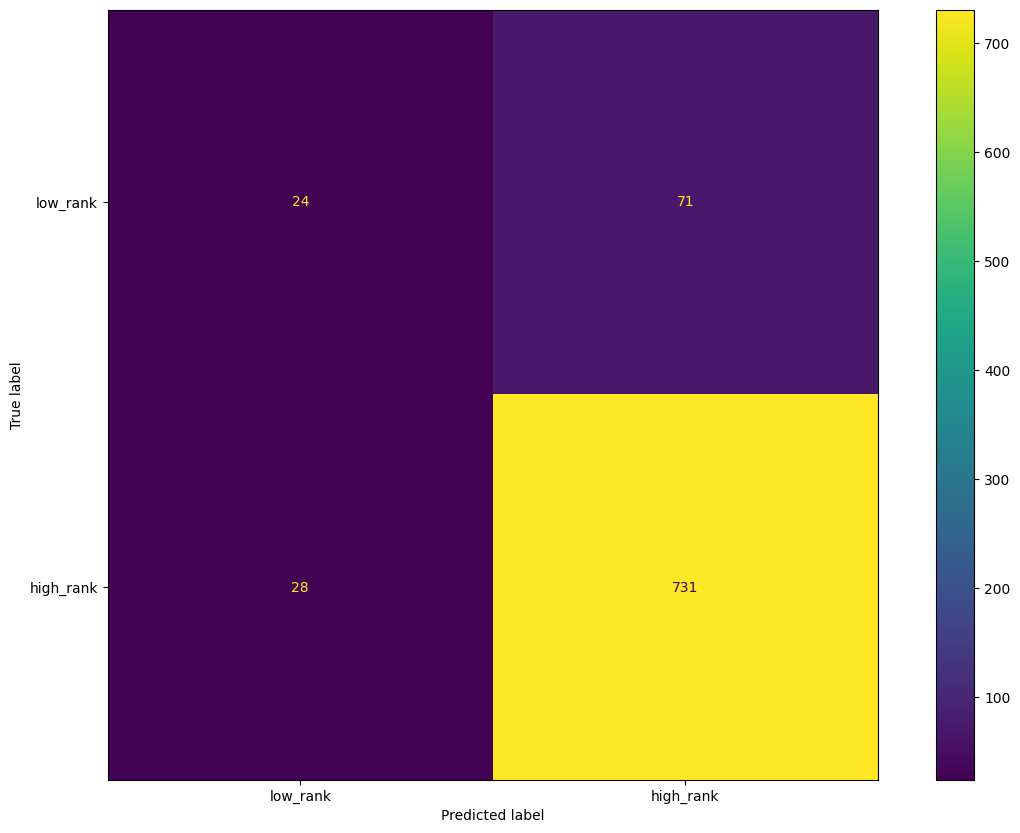

In [23]:
print(classification_report(y_true, y_codebert_test_pred, target_names=['low_rank','high_rank']))

print("f1_score_macro : ",f1_score(y_true, y_codebert_test_pred, average='macro'))
print("f1_score_weighted : ",f1_score(y_true, y_codebert_test_pred, average='weighted'))

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_true, y_codebert_test_pred), display_labels=['low_rank','high_rank'])

fig, ax = plt.subplots(figsize=(15,10))
disp.plot(ax=ax)

plt.show()

In [24]:
# Test the model and print out the confusion matrix
model.eval()
y_true = []
y_codebert_train_pred = []
with torch.no_grad():
    for batch in train_dataloader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        predictions = torch.argmax(logits, dim=1)
        y_true += labels.tolist()
        y_codebert_train_pred += predictions.tolist()

              precision    recall  f1-score   support

    low_rank       0.92      0.73      0.81       332
   high_rank       0.97      0.99      0.98      2657

    accuracy                           0.96      2989
   macro avg       0.94      0.86      0.90      2989
weighted avg       0.96      0.96      0.96      2989

f1_score_macro :  0.896412453147709
f1_score_weighted :  0.960948568693625


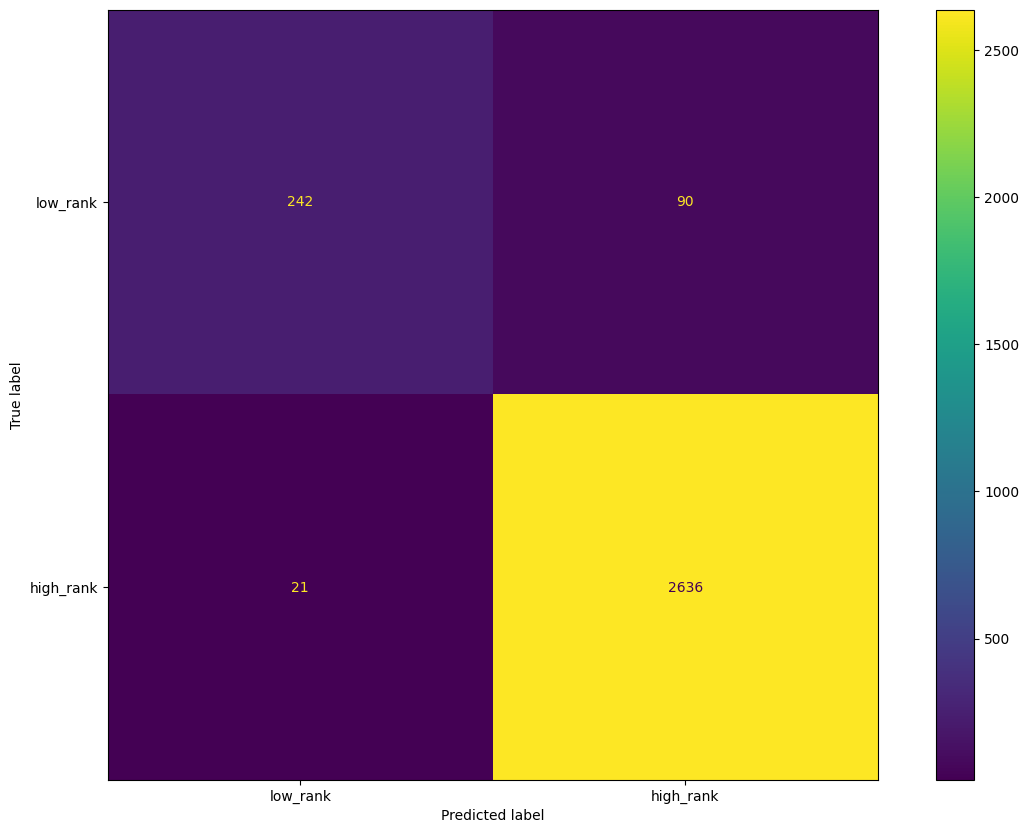

In [25]:
print(classification_report(y_true, y_codebert_train_pred, target_names=['low_rank','high_rank']))

print("f1_score_macro : ",f1_score(y_true, y_codebert_train_pred, average='macro'))
print("f1_score_weighted : ",f1_score(y_true, y_codebert_train_pred, average='weighted'))

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_true, y_codebert_train_pred), display_labels=['low_rank','high_rank'])

fig, ax = plt.subplots(figsize=(15,10))
disp.plot(ax=ax)

plt.show()